In [7]:
from analyze_runs import load_sweep_run, plot_multi_mean_std_curves, plot_generalization_heatmaps, plot_multi_spectra, load_sweep_data_from_path, plot_jacobian_singular_vectors
from core.mail import email_pdf
# 1. Load both runs
# td_config, td_metrics, td_summary = load_sweep_run("results/random/td_exact/tuning")
# mc_config, mc_metrics, mc_summary = load_sweep_run("results/random/mc_exact/tuning")

# steps_per_pi = td_config.get("NUM_ENVS", 1) * td_config.get("NUM_STEPS", 1)

# # 2. Compare Value Error (nn_weighted_VE) on the same plot with mean & std
# plot_multi_mean_std_curves(
#     {
#         "Exact TD": td_metrics["nn_weighted_VE"],
#         "Exact MC": mc_metrics["nn_weighted_VE"]
#     },
#     steps_per_pi=steps_per_pi,
#     metric_name="Value Error",
#     ylabel="MSVE (nn_weighted_VE)",
#     log_scale=True, tuning_summaries = {"Expected TD": td_summary, "Supervised Value Learning": mc_summary}
# )

Loaded sweep run from results/random/mc_exact/lr_decay_sweep/tuning/20260819_220425/FourRooms-misc
Loaded sweep run from results/random/td_exact/lr_decay_sweep/tuning/20260819_220417/FourRooms-misc
[Exact TD] Using best combo index 3 from tuning summary.
number of seeds: 10
[Exact MC] Using best combo index 3 from tuning summary.
number of seeds: 10


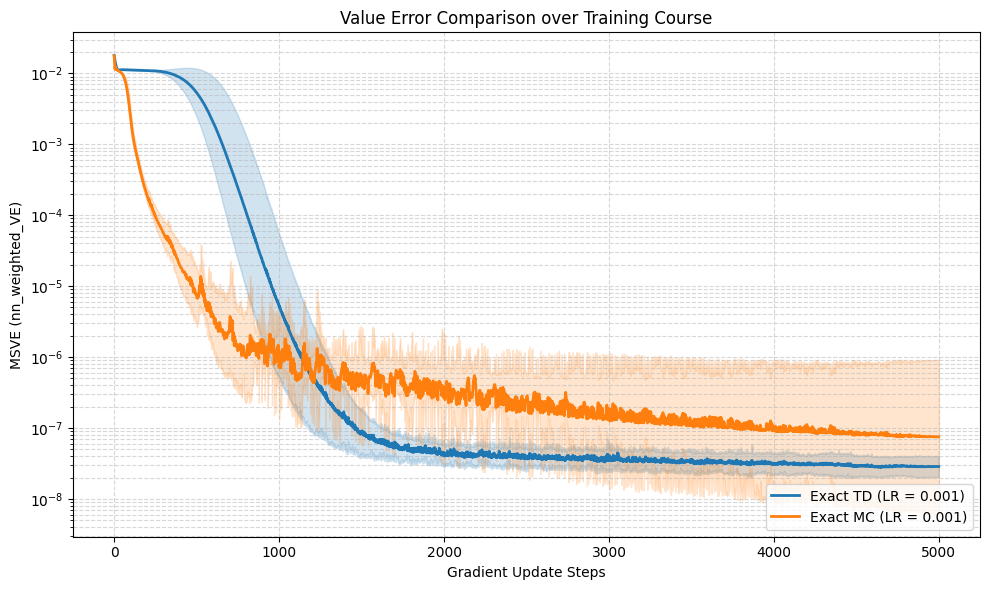

📁 Found figures/td_vs_mc_tuned.pdf (262.4 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [2]:
# 1. Load both runs
mc_config, mc_metrics, mc_summary= load_sweep_data_from_path("results/random/mc_exact/lr_decay_sweep/tuning/20260819_220425/FourRooms-misc")
td_config, td_metrics, td_summary = load_sweep_data_from_path("results/random/td_exact/lr_decay_sweep/tuning/20260819_220417/FourRooms-misc")

steps_per_pi = td_config.get("NUM_ENVS", 1) * td_config.get("NUM_STEPS", 1)

# 2. Compare Value Error (nn_weighted_VE) on the same plot with mean & std
fig = plot_multi_mean_std_curves(
    {
        "Exact TD": td_metrics["nn_weighted_VE"],
        "Exact MC": mc_metrics["nn_weighted_VE"]
    },
    steps_per_pi=steps_per_pi,
    metric_name="Value Error",
    ylabel="MSVE (nn_weighted_VE)",
    log_scale=True, tuning_summaries = {"Exact TD": td_summary, "Exact MC": mc_summary}
)
fig.savefig('figures/td_vs_mc_tuned.pdf', bbox_inches='tight')
email_pdf('figures/td_vs_mc_tuned.pdf')


In [3]:
# # 1. Load both runs
# mc_config, mc_metrics, mc_summary= load_sweep_run("results/random/mc_exact/lr_fixed_sweep/tuning/")
# td_config, td_metrics, td_summary = load_sweep_run("results/random/td_exact/lr_fixed_sweep/tuning/")

# steps_per_pi = td_config.get("NUM_ENVS", 1) * td_config.get("NUM_STEPS", 1)

# # 2. Compare Value Error (nn_weighted_VE) on the same plot with mean & std
# plot_multi_mean_std_curves(
#     {
#         "Exact TD": td_metrics["nn_weighted_VE"],
#         "Exact MC": mc_metrics["nn_weighted_VE"]
#     },
#     steps_per_pi=steps_per_pi,
#     metric_name="Value Error",
#     ylabel="MSVE (nn_weighted_VE)",
#     log_scale=True, tuning_summaries = {"Exact TD": td_summary, "Exact MC": mc_summary}
# )

number of seeds: 1
number of seeds: 1


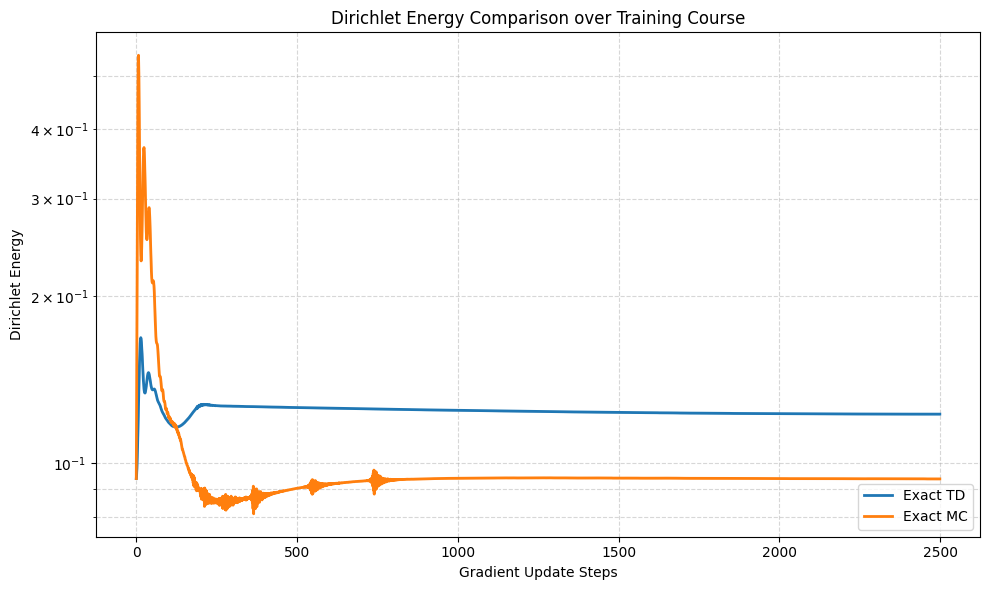

In [4]:

from core.utils import load_run_data_from_path
td_config_tuned, td_metrics_tuned = load_run_data_from_path("results/random/td_exact/tuned_saved_metrics/FourRooms-misc")
mc_config_tuned, mc_metrics_tuned = load_run_data_from_path("results/random/mc_exact/tuned_saved_metrics/FourRooms-misc")
# E_config_tuned, E_metrics_tuned = load_run_data_from_path("results/random/exact_E/tuned_lr_decay/FourRooms-misc")

# 3. Reuse the exact same function for Dirichlet Energy (E) comparison
fig = plot_multi_mean_std_curves(
    {
        "Exact TD": td_metrics_tuned["Direlechet_energy"],
        "Exact MC": mc_metrics_tuned["Direlechet_energy"]
    },
    steps_per_pi=steps_per_pi,
    metric_name="Dirichlet Energy",
    ylabel="Dirichlet Energy",
    log_scale=True
)

📁 Found figures/jacobian_svals.pdf (19.4 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

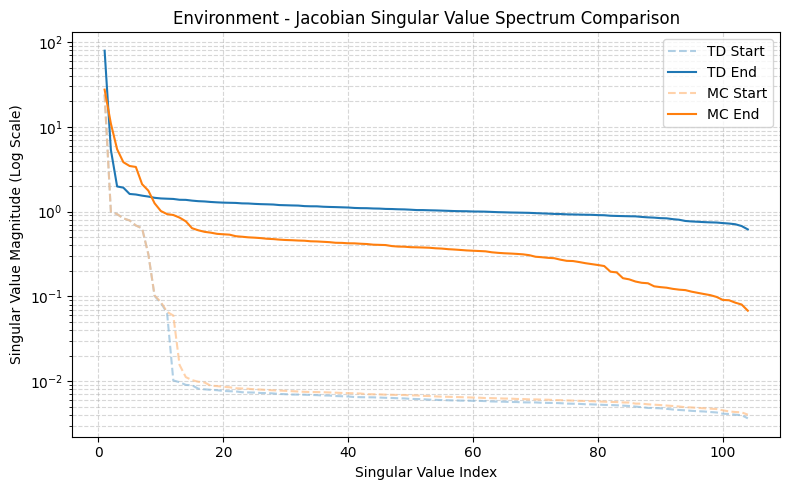

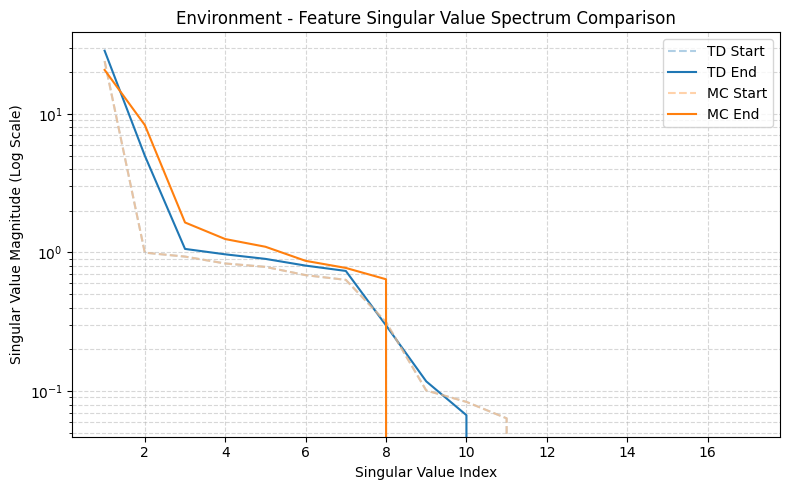

In [10]:

# 4. Compare generalization heatmaps and spectra

figs = plot_multi_spectra({"TD": td_metrics_tuned, "MC": mc_metrics_tuned})

figs[0].savefig('figures/jacobian_svals.pdf', bbox_inches='tight')
email_pdf('figures/jacobian_svals.pdf')

📁 Found figures/td_jacobian_svectors.pdf (28.1 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

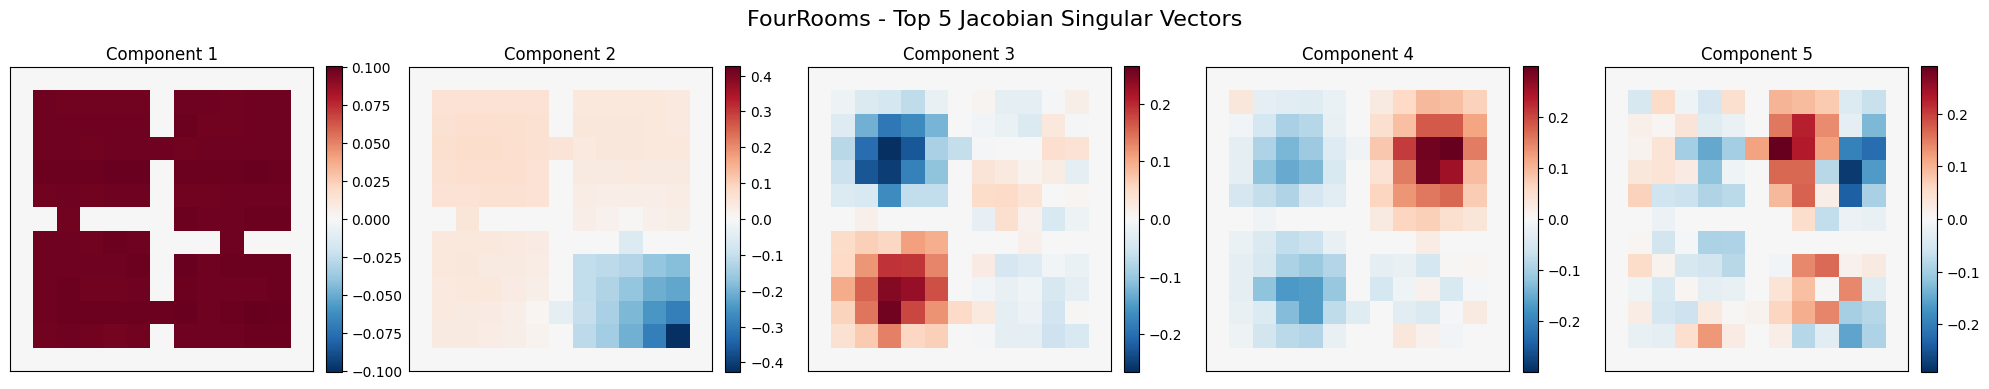

In [11]:
fig = plot_jacobian_singular_vectors(td_metrics_tuned, "FourRooms")
fig.savefig('figures/td_jacobian_svectors.pdf', bbox_inches='tight')
email_pdf('figures/td_jacobian_svectors.pdf')

📁 Found figures/mc_jacobian_svectors.pdf (28.0 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

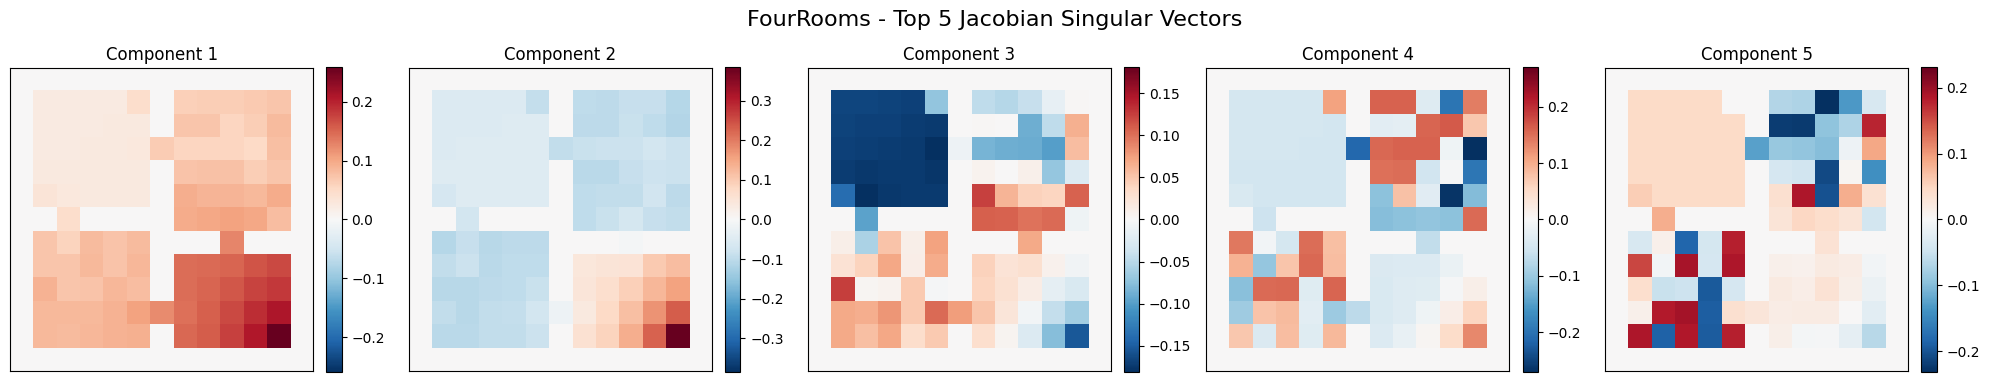

In [13]:
fig = plot_jacobian_singular_vectors(mc_metrics_tuned, "FourRooms")
fig.savefig('figures/mc_jacobian_svectors.pdf', bbox_inches='tight')
email_pdf('figures/mc_jacobian_svectors.pdf')

📁 Found figures/Uncentered TD vs MC.pdf (33.5 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

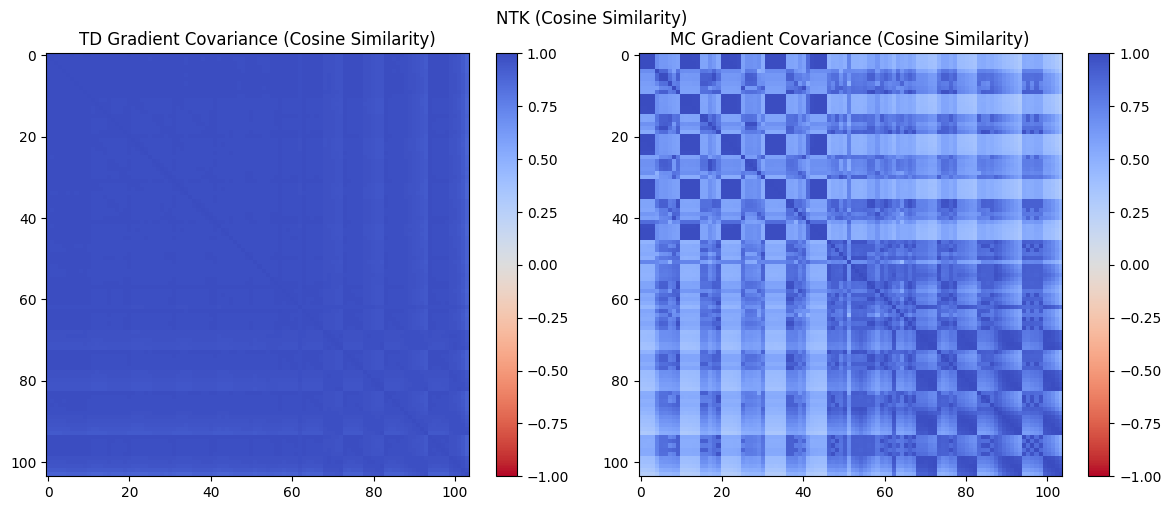

In [ ]:

def get_cosine_sim(K):
    # Extract the diagonal (squared gradient norms)
    diag = jnp.diag(K)
    # Compute norms (add epsilon to prevent division by zero for dead states)
    norms = jnp.sqrt(jnp.clip(diag, a_min=1e-12))
    # Normalize the covariance matrix by the outer product of the norms
    return K / jnp.outer(norms, norms)

# You can also use gradient_covariance_matrix if you prefer it centered
sim_td = get_cosine_sim(td_metrics_tuned["eNTK"][0,-1])
sim_mc = get_cosine_sim(mc_metrics_tuned["eNTK"][0, -1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cosine similarity is strictly bounded between -1 and 1
cmap = "coolwarm_r"

im0 = axes[0].imshow(sim_td, cmap=cmap, vmin=-1.0, vmax=1.0)
axes[0].set_title("TD Gradient Covariance (Cosine Similarity)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sim_mc, cmap=cmap, vmin=-1.0, vmax=1.0)
axes[1].set_title("MC Gradient Covariance (Cosine Similarity)")
fig.colorbar(im1, ax=axes[1])
fig.suptitle('NTK (Cosine Similarity)')

plt.tight_layout()
fig.savefig('figures/Uncentered TD vs MC.pdf', bbox_inches='tight')
email_pdf('figures/Uncentered TD vs MC.pdf')


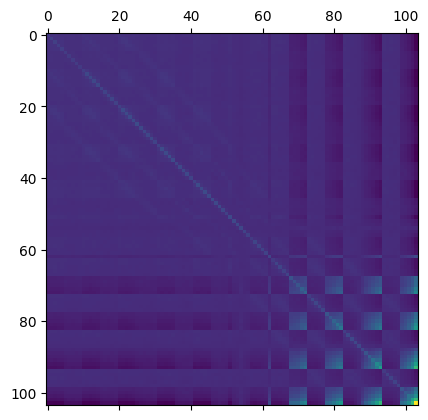

In [ ]:
import matplotlib.pyplot as plt

plt.matshow(td_metrics_tuned['gradient_covariance_matrix'][0,-1])

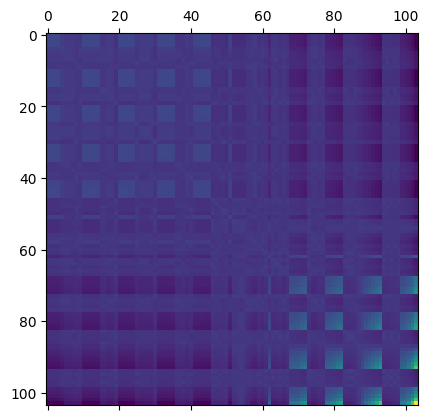

In [ ]:
plt.matshow(mc_metrics_tuned['gradient_covariance_matrix'][0,-1])

Loaded sweep run from results/random/mc_exact/lr_decay_sweep/tuning/20260819_220425/FourRooms-misc
Loaded sweep run from results/random/td_exact/lr_decay_sweep/tuning/20260819_220417/FourRooms-misc
Loaded sweep run from results/random/exact_E/lr_decay_sweep/tuning/20260819_220356/FourRooms-misc
[Exact TD] Using best combo index 3 from tuning summary.
number of seeds: 10
[Exact MC] Using best combo index 3 from tuning summary.
number of seeds: 10
label GD on E not in tuning summaries
[GD on E] Using best combo index 4 from 3D tensor.
number of seeds: 10


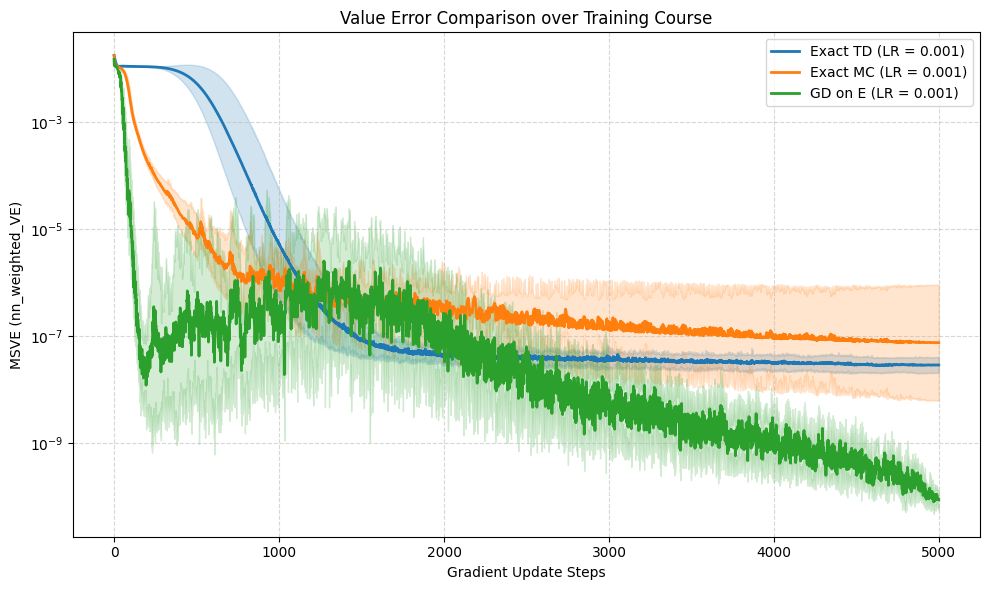

In [ ]:
# 1. Load both runs
mc_config, mc_metrics, mc_summary= load_sweep_data_from_path("results/random/mc_exact/lr_decay_sweep/tuning/20260819_220425/FourRooms-misc")
td_config, td_metrics, td_summary = load_sweep_data_from_path("results/random/td_exact/lr_decay_sweep/tuning/20260819_220417/FourRooms-misc")
E_config, E_metrics, E_summary = load_sweep_run("results/random/exact_E/lr_decay_sweep/tuning")

steps_per_pi = td_config.get("NUM_ENVS", 1) * td_config.get("NUM_STEPS", 1)

# 2. Compare Value Error (nn_weighted_VE) on the same plot with mean & std
plot_multi_mean_std_curves(
    {
        "Exact TD": td_metrics["nn_weighted_VE"],
        "Exact MC": mc_metrics["nn_weighted_VE"],
        "GD on E": E_metrics["nn_weighted_VE"]
    },
    steps_per_pi=steps_per_pi,
    metric_name="Value Error",
    ylabel="MSVE (nn_weighted_VE)",
    log_scale=True, tuning_summaries = {"Exact TD": td_summary, "Exact MC": mc_summary}
)


In [ ]:

from core.utils import load_run_data_from_path
td_config_tuned, td_metrics_tuned = load_run_data_from_path("results/random/td_exact/tuned_lr_decay/FourRooms-misc")
mc_config_tuned, mc_metrics_tuned = load_run_data_from_path("results/random/mc_exact/tuned_lr_decay/FourRooms-misc")
E_config_tuned, E_metrics_tuned = load_run_data_from_path("results/random/exact_E/tuned_lr_decay/FourRooms-misc")

# 3. Reuse the exact same function for Dirichlet Energy (E) comparison
plot_multi_mean_std_curves(
    {
        "Exact TD": td_metrics_tuned["Direlechet_energy"],
        "Exact MC": mc_metrics_tuned["Direlechet_energy"],
        "GD on E": E_metrics["Direlechet_energy"]

    },
    steps_per_pi=steps_per_pi,
    metric_name="Dirichlet Energy",
    ylabel="Dirichlet Energy",
    log_scale=True
)

KeyError: 'Direlechet_energy'